In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error, r2_score

import mlflow
import mlflow.sklearn

import joblib

In [37]:
flights = pd.read_csv(r"C:\Users\shourya\Desktop\travel-mlops-project\data\flights.csv")
flights.head()

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019


In [38]:
print(flights.shape)

flights.info()
flights.describe()
flights.duplicated().sum()

(271888, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   travelCode  271888 non-null  int64  
 1   userCode    271888 non-null  int64  
 2   from        271888 non-null  object 
 3   to          271888 non-null  object 
 4   flightType  271888 non-null  object 
 5   price       271888 non-null  float64
 6   time        271888 non-null  float64
 7   distance    271888 non-null  float64
 8   agency      271888 non-null  object 
 9   date        271888 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 20.7+ MB


np.int64(0)

In [39]:
flights['date'] = pd.to_datetime(flights['date'])



In [40]:
flights['year'] = flights['date'].dt.year
flights['month'] = flights['date'].dt.month
flights['day'] = flights['date'].dt.day
flights['weekday'] = flights['date'].dt.weekday

In [41]:
flights = flights.drop(columns=['travelCode', 'userCode', 'date'])

In [42]:
X = flights.drop('price', axis=1)

y = flights['price']

In [43]:
categorical_features = X.select_dtypes(include=['object']).columns

numerical_features = X.select_dtypes(exclude=['object']).columns

print(categorical_features)

print(numerical_features)

Index(['from', 'to', 'flightType', 'agency'], dtype='object')
Index(['time', 'distance', 'year', 'month', 'day', 'weekday'], dtype='object')


In [44]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [58]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42
    )
}

In [59]:
results = []

In [60]:
mlflow.set_experiment("Flight_Price_Prediction")

for model_name, model in models.items():

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    with mlflow.start_run(run_name=model_name):

        # Train
        pipeline.fit(X_train, y_train)

        # Predict
        predictions = pipeline.predict(X_test)

        # Metrics
        rmse = np.sqrt(mean_squared_error(y_test, predictions))
        r2 = r2_score(y_test, predictions)

        # Store results
        results.append({
            'Model': model_name,
            'RMSE': rmse,
            'R2 Score': r2
        })

        # MLflow logging
        mlflow.log_param("model_name", model_name)
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("r2_score", r2)

        # Log model
        mlflow.sklearn.log_model(pipeline, model_name)

        print(f"{model_name} completed")

2026/05/18 15:35:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/18 15:35:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Linear Regression completed


2026/05/18 15:36:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/18 15:36:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Random Forest completed


2026/05/18 15:37:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/18 15:37:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost completed


In [61]:
results_df = pd.DataFrame(results)



In [ ]:
results_df.sort_values(by='R2 Score', ascending=False)

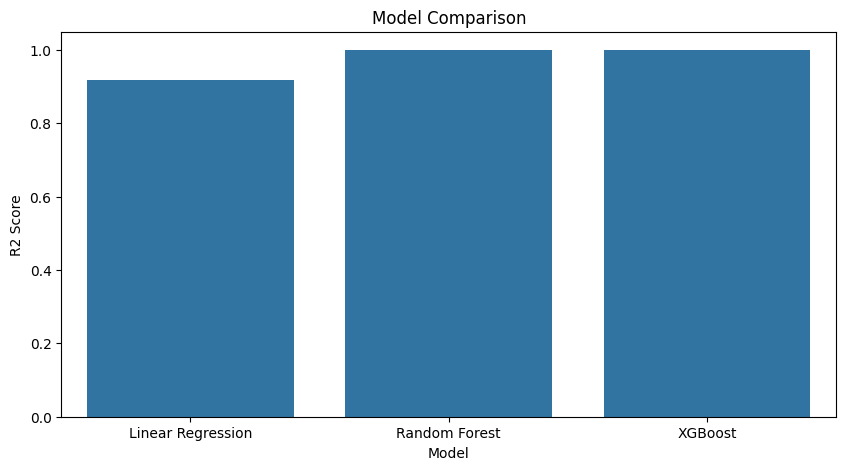

In [50]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x='Model',
    y='R2 Score'
)

plt.title("Model Comparison")
plt.show()

In [62]:
best_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42
    ))
])

best_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [63]:
joblib.dump(best_model, "../models/flight_price_model.pkl")

['../models/flight_price_model.pkl']

In [64]:
import os

os.listdir("../models")

['flight_price_model.pkl']